# 5.3 CAPM 与套利定价理论 (CAPM & APT)

## 学习目标
- 理解 CAPM 的核心假设和结论
- 绘制证券市场线 (SML) 并解读 Alpha
- 了解多因子 APT 如何扩展 CAPM
- 实践：用历史数据估计单只股票的 Alpha 和 Beta


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
np.random.seed(42)
print('Libraries loaded')


Libraries loaded


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 1. CAPM 核心公式

资本资产定价模型 (CAPM) 假设市场是均衡的，每只股票的预期收益由一个简单关系决定：

$$E[R_i] = R_f + \beta_i \cdot (E[R_m] - R_f)$$

- $R_f$：无风险利率（国债收益率）
- $E[R_m] - R_f$：市场风险溢价（Market Risk Premium，约 4%~7%）
- $\beta_i$：股票对市场的系统性风险暴露
- $E[R_i]$：股票的理论预期收益率

**证券市场线 (Security Market Line, SML)** 是所有均衡资产应该落在的直线。
偏离 SML 的距离就是 **Alpha**——超越市场理论预期的超额收益。


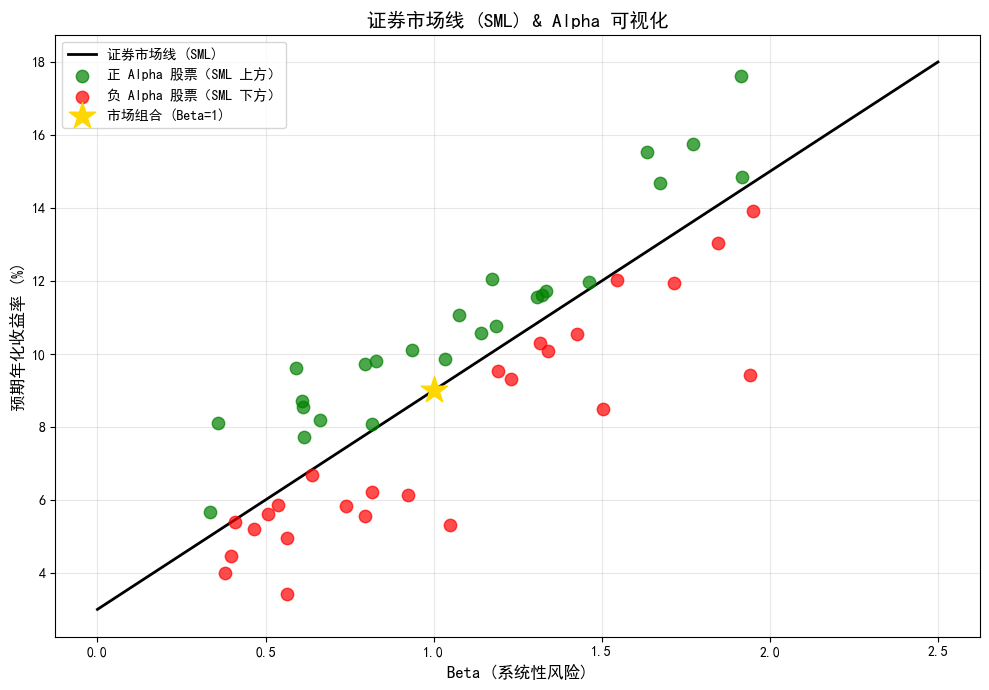

正 Alpha 股票: 25 只
负 Alpha 股票: 25 只


In [3]:
# 绘制证券市场线 (SML)
np.random.seed(42)
risk_free = 0.03        # 无风险利率 3%
market_premium = 0.06   # 市场溢价 6%

# 模拟 50 只股票的 Beta 和实际年化收益率
betas = np.random.uniform(0.3, 2.0, 50)
alphas = np.random.normal(0, 0.02, 50)  # 各股真实 Alpha（正负随机）
actual_returns = risk_free + betas * market_premium + alphas

# SML
beta_range = np.linspace(0, 2.5, 100)
sml_returns = risk_free + beta_range * market_premium

plt.figure(figsize=(10, 7))
plt.plot(beta_range, sml_returns * 100, 'k-', linewidth=2, label='证券市场线 (SML)')

# 绘制各股票，颜色区分 Alpha 正负
positive_alpha = actual_returns > (risk_free + betas * market_premium)
plt.scatter(betas[positive_alpha], actual_returns[positive_alpha] * 100,
            color='green', s=80, alpha=0.7, label='正 Alpha 股票（SML 上方）', zorder=5)
plt.scatter(betas[~positive_alpha], actual_returns[~positive_alpha] * 100,
            color='red', s=80, alpha=0.7, label='负 Alpha 股票（SML 下方）', zorder=5)

# 标注市场组合 (Beta=1)
plt.scatter([1.0], [(risk_free + market_premium) * 100], marker='*', s=400,
            color='gold', zorder=6, label='市场组合 (Beta=1)')

plt.xlabel('Beta (系统性风险)', fontsize=12)
plt.ylabel('预期年化收益率 (%)', fontsize=12)
plt.title('证券市场线 (SML) & Alpha 可视化', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'正 Alpha 股票: {positive_alpha.sum()} 只')
print(f'负 Alpha 股票: {(~positive_alpha).sum()} 只')


## 2. 用 OLS 估计单只股票的 Alpha 和 Beta


In [4]:
n = 252  # 一年
market_returns = np.random.normal(0.06/252, 0.18/np.sqrt(252), n)
stock_returns = 0.0003 + 1.25 * market_returns + np.random.normal(0, 0.008, n)

X = sm.add_constant(market_returns)
result = sm.OLS(stock_returns, X).fit()

print(f'估计 Alpha（日）: {result.params[0]:.6f}   (年化: {result.params[0]*252:.4f})')
print(f'估计 Beta:        {result.params[1]:.4f}')
print(f'R-squared:        {result.rsquared:.4f}')
print(f'Alpha p-value:    {result.pvalues[0]:.4f}  ← 是否显著不为零？')


估计 Alpha（日）: -0.000032   (年化: -0.0081)
估计 Beta:        1.2081
R-squared:        0.7345
Alpha p-value:    0.9492  ← 是否显著不为零？


## 3. 多因子 APT

APT（套利定价理论）将 CAPM 中单一的市场因子扩展为多因子模型：

$$E[R_i] = R_f + \beta_{i,1} f_1 + \beta_{i,2} f_2 + ... + \beta_{i,K} f_K$$

常见因子（Fama-French 模型）：
- **f1**: 市场因子（CAPM 的 Rm-Rf）
- **f2**: SMB（小市值 - 大市值）
- **f3**: HML（高账面市值比 - 低账面市值比）


In [5]:
# Fama-French 三因子简化演示
Mkt_Rf = np.random.normal(0.0002, 0.01, n)  # 市场超额收益率
SMB    = np.random.normal(0.0001, 0.005, n) # 规模因子
HML    = np.random.normal(0.0001, 0.005, n) # 价值因子

X_ff3 = sm.add_constant(np.column_stack([Mkt_Rf, SMB, HML]))
result_ff3 = sm.OLS(stock_returns - 0.03/252, X_ff3).fit()

print('Fama-French 三因子模型回归结果：')
print(f'Alpha: {result_ff3.params[0]:.6f} (年化: {result_ff3.params[0]*252:.4f})')
print(f'Beta_Mkt:  {result_ff3.params[1]:.4f}')
print(f'Beta_SMB:  {result_ff3.params[2]:.4f}  (正值=偏小市值)')
print(f'Beta_HML:  {result_ff3.params[3]:.4f}  (正值=偏价值股)')
print(f'R-squared: {result_ff3.rsquared:.4f}  (更高意味着三因子解释力更强)')


Fama-French 三因子模型回归结果：
Alpha: 0.000700 (年化: 0.1765)
Beta_Mkt:  0.1260
Beta_SMB:  0.0706  (正值=偏小市值)
Beta_HML:  0.1019  (正值=偏价值股)
R-squared: 0.0088  (更高意味着三因子解释力更强)


## 🎯 练习

1. 用 SPY，QQQ，GLD 三个不同 Beta 的 ETF，在同一个 SML 上标注它们的实际历史年化收益率，看谁真正有 Alpha。
2. 对比单因子 CAPM 和 Fama-French 三因子上同一只股票的 R-squared，三因子是否解释了更多方差？
3. 修改代码模拟一只高 Alpha（年化 +5%）且低 Beta（0.3）的股票，在 SML 图上它会在什么位置？

---
**下一节** → `04_factor_analysis.ipynb`
